# Análise de Dados — Carcinoma Basocelular (PIBIC / LMECC)

Estudo retrospectivo de biópsias de carcinoma basocelular (CBC). Este notebook faz o
**tratamento/limpeza** dos dados, a **representação** (tabelas + gráficos) e a
**análise estatística** das associações clínico-patológicas.

**Unidade de análise (definida com a equipe):**
- **Por paciente** (deduplicado pelo *Código da Amostra*): perfil demográfico — idade, sexo, profissão — e a comparação de idade entre sexos.
- **Por lesão** (todos os registros): as tabelas cruzadas histopatológicas (uma biópsia = uma lesão).

**Análises solicitadas:**
1. Subtipo do Tumor × Grau de infiltração
2. Subtipo do Tumor × Ulceração
3. Subtipo do Tumor × Invasão Linfovascular
4. Subtipo do Tumor × Invasão Perineural
5. Margens comprometidas × Reincidência
6. Perfil descritivo (idade, sexo, profissão) + comparação da idade média Homens × Mulheres


## 0. Configuração do ambiente

In [1]:
import os, re, unicodedata, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150,
                     "savefig.bbox": "tight", "axes.titleweight": "bold",
                     "font.size": 11})

ARQUIVO = "Dados_PIBIC_LMECC_Completo (1).xlsx"
FIG_DIR = "figuras"
os.makedirs(FIG_DIR, exist_ok=True)

def salvar_fig(nome):
    plt.savefig(os.path.join(FIG_DIR, nome))
    print(f"[figura salva] {os.path.join(FIG_DIR, nome)}")
print("Ambiente pronto.")

Ambiente pronto.


## 1. Carga dos dados

Lemos a aba **Banco de Dados**. Cada linha é uma lesão biopsiada.

In [2]:
brutos = pd.read_excel(ARQUIVO, sheet_name="Banco de Dados")
print("Dimensões (linhas x colunas):", brutos.shape)
print("\nColunas:")
for c in brutos.columns: print("  -", c)
brutos.head()

Dimensões (linhas x colunas): (419, 20)

Colunas:
  - Código da Amostra
  - Data do diagnóstico
  - Tipo de Material Analisado
  - Idade ao diagnóstico
  - Sexo
  - Etnia
  - Estado Civil
  - Profissão
  - Subtipo do Tumor
  - Região Anatômica da Lesão
  - Tamanho da Lesão (cm)
  - Presença de Ulceração
  - infiltração
  - Estado de Comprometimento das Margens (Lateral)
  - Estado de Comprometimento das Margens (Profunda)
  - Reincidência?
  - Quantas reincidências?
  - Invasão Linfovascular?
  - Invasão Perineural?
  - Tratamento


,Código da Amostra,Data do diagnóstico,Tipo de Material Analisado,Idade ao diagnóstico,Sexo,Etnia,Estado Civil,Profissão,Subtipo do Tumor,Região Anatômica da Lesão,Tamanho da Lesão (cm),Presença de Ulceração,infiltração,Estado de Comprometimento das Margens (Lateral),Estado de Comprometimento das Margens (Profunda),Reincidência?,Quantas reincidências?,Invasão Linfovascular?,Invasão Perineural?,Tratamento
0,77043,2022,Biópsia,70,Masculino,Branca,Divorciado(a),advogado,basoescamoso,dorso,1,Não,derme reticular,livres,livres,Não,NaN,Não,Não,NaN
1,71171,2021,Biópsia,78,Masculino,Negra,Casado(a),trabalhador agrícola,misto (solido e basoescamoso),face (nariz),2.3,Sim,derme reticular média,livres,livres,Não,NaN,Não,Não,NaN
2,55704,2020,Biópsia,81,Feminino,Branca,Casado(a),aposentada,misto (superficial e esclerodermiforme),face (frontal),1.6,Não,NaN,livres,livres,NaN,NaN,NaN,Não,NaN
3,55704,2022,Biópsia,83,Feminino,Branca,Casado(a),aposentada,misto (sólido e esclerodermiforme),face (palpebra),1,Sim,derme reticular profunda,livres,livres,Não,NaN,NaN,Não,NaN
4,55704,2022,Biópsia,83,Feminino,Branca,Casado(a),aposentada,misto (sólido e esclerodermiforme),face (periorbital),0.7,Não,derme reticular profunda,livres,comprometida,Não,NaN,NaN,Não,NaN


## 2. Tratamento e limpeza dos dados

A base apresenta inconsistências típicas de digitação manual. Tratamentos aplicados:

| Coluna | Problema | Tratamento |
|---|---|---|
| Idade ao diagnóstico | `não informado` e vazios | converter para numérico, inválidos → ausente |
| Etnia | `branca` vs `Branca` | padronizar capitalização |
| Estado Civil | valor `Branca` infiltrado (erro) | remover → ausente |
| Profissão | maiúsc./acentos, `aposentado`/`aposentada` | normalizar + agrupar por setor |
| **Subtipo do Tumor** | 58 variações de `misto (...)`, acentos, erros de digitação | normalizar; criar `composição` (puro/misto) + **flags de componente** |
| **infiltração** (grau) | 32 variações | escala ordinal de profundidade (Derme → Derme reticular → Hipoderme → Estruturas profundas) |
| Ulceração | `Não informado` | manter Sim/Não; `Não informado` → ausente |
| Margens (Lateral/Profunda) | `comprometidas (1)`, espaços | normalizar para *livre*/*comprometida*; criar flag combinada |
| Reincidência | `Talvez`, vazios | manter Sim/Não; demais → ausente |
| Invasão Linfovascular | só `Não`/vazio (**sem positivos**) | manter, sinalizar limitação |
| Invasão Perineural | vazios | manter Sim/Não |
| Tratamento / Tipo de Material | constantes/vazias | descartar |


In [3]:
def sem_acento(s):
    if pd.isna(s): return s
    s = unicodedata.normalize("NFKD", str(s))
    return "".join(c for c in s if not unicodedata.combining(c))

def norm(s):
    # minúsculas, sem acento, espaços colapsados
    if pd.isna(s): return np.nan
    s = sem_acento(str(s)).lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s if s else np.nan

df = brutos.copy()
# nomes de coluna curtos
df = df.rename(columns={
    "Código da Amostra": "codigo",
    "Data do diagnóstico": "data_dx",
    "Idade ao diagnóstico": "idade",
    "Sexo": "sexo",
    "Etnia": "etnia",
    "Estado Civil": "estado_civil",
    "Profissão": "profissao",
    "Subtipo do Tumor": "subtipo_raw",
    "Região Anatômica da Lesão": "regiao",
    "Tamanho da Lesão (cm)": "tamanho_cm",
    "Presença de Ulceração": "ulceracao",
    "infiltração": "infiltracao_raw",
    "Estado de Comprometimento das Margens (Lateral)": "margem_lat_raw",
    "Estado de Comprometimento das Margens (Profunda)": "margem_prof_raw",
    "Reincidência?": "reincidencia",
    "Quantas reincidências?": "qtd_reincidencias",
    "Invasão Linfovascular?": "inv_linfovascular",
    "Invasão Perineural?": "inv_perineural",
})
df = df.drop(columns=[c for c in ["Tipo de Material Analisado", "Tratamento"] if c in df.columns])
print("Colunas após renomear/descartar:", list(df.columns))

Colunas após renomear/descartar: ['codigo', 'data_dx', 'idade', 'sexo', 'etnia', 'estado_civil', 'profissao', 'subtipo_raw', 'regiao', 'tamanho_cm', 'ulceracao', 'infiltracao_raw', 'margem_lat_raw', 'margem_prof_raw', 'reincidencia', 'qtd_reincidencias', 'inv_linfovascular', 'inv_perineural']


In [4]:
# --- Idade ---
df["idade"] = pd.to_numeric(df["idade"], errors="coerce")

# --- Sexo ---
df["sexo"] = df["sexo"].str.strip().str.title()

# --- Etnia ---
df["etnia"] = df["etnia"].str.strip().str.title()

# --- Estado civil: 'Branca' é erro de digitação ---
df["estado_civil"] = df["estado_civil"].where(df["estado_civil"] != "Branca")
df["estado_civil"] = df["estado_civil"].str.strip()

# --- Ulceração ---
u = df["ulceracao"].apply(norm)
df["ulceracao"] = u.map({"sim": "Sim", "nao": "Não"})  # 'nao informado' -> NaN

# --- Reincidência ---
r = df["reincidencia"].apply(norm)
df["reincidencia"] = r.map({"sim": "Sim", "nao": "Não"})  # 'talvez'/vazio -> NaN

# --- Invasão perineural / linfovascular ---
df["inv_perineural"] = df["inv_perineural"].apply(norm).map({"sim": "Sim", "nao": "Não"})
df["inv_linfovascular"] = df["inv_linfovascular"].apply(norm).map({"sim": "Sim", "nao": "Não"})
print("Idade: n válidos =", df["idade"].notna().sum(), "| faixa =", (df["idade"].min(), df["idade"].max()))
print("Ulceração:\n", df["ulceracao"].value_counts(dropna=False))
print("\nInvasão linfovascular:\n", df["inv_linfovascular"].value_counts(dropna=False))

Idade: n válidos = 417 | faixa = (np.float64(26.0), np.float64(100.0))
Ulceração:
 ulceracao
Sim    268
Não    147
NaN      4
Name: count, dtype: int64

Invasão linfovascular:
 inv_linfovascular
NaN    219
Não    200
Name: count, dtype: int64


### 2.1. Margens — normalização e flag combinada
Texto livre (`comprometidas (1)`, `comprometida`, espaços) → categoria *livre* / *comprometida*.
A flag **`margem_comprometida`** marca *Sim* quando a margem **lateral OU profunda** estiver comprometida.

In [5]:
def normaliza_margem(s):
    s = norm(s)
    if pd.isna(s): return np.nan
    if "comprometid" in s: return "Comprometida"
    if "livre" in s: return "Livre"
    return np.nan  # 'nao informado'

df["margem_lateral"]  = df["margem_lat_raw"].apply(normaliza_margem)
df["margem_profunda"] = df["margem_prof_raw"].apply(normaliza_margem)

def combina_margem(row):
    vals = [row["margem_lateral"], row["margem_profunda"]]
    if "Comprometida" in vals: return "Comprometida"
    if "Livre" in vals: return "Livre"
    return np.nan
df["margem_comprometida"] = df.apply(combina_margem, axis=1)

print(pd.crosstab(df["margem_lateral"], df["margem_profunda"],
                  dropna=False, margins=True))
print("\nFlag combinada (margem_comprometida):")
print(df["margem_comprometida"].value_counts(dropna=False))

margem_profunda  Comprometida  Livre  NaN  All
margem_lateral                                
Comprometida               11     28    0   39
Livre                      14    363    0  377
NaN                         0      0    3    3
All                        25    391    3  419

Flag combinada (margem_comprometida):
margem_comprometida
Livre           363
Comprometida     53
NaN               3
Name: count, dtype: int64


### 2.2. Grau de infiltração — escala ordinal de profundidade
As 32 variantes são mapeadas por palavra-chave para uma escala de profundidade crescente:

1. **Derme** (papilar/superficial/média)
2. **Derme reticular** (inclui derme profunda)
3. **Hipoderme / tecido subcutâneo**
4. **Estruturas profundas** (músculo, cartilagem, globo ocular, tecidos periorbitários)

In [6]:
ORDEM_GRAU = ["1. Derme", "2. Derme reticular", "3. Hipoderme/subcutâneo",
              "4. Estruturas profundas"]

def classifica_grau(s):
    s = norm(s)
    if pd.isna(s) or "nao informado" in s: return np.nan
    # mais profundo primeiro
    if any(k in s for k in ["globo ocular", "muscul", "musc", "cartilagem", "periorbit", "estriad"]):
        return "4. Estruturas profundas"
    if any(k in s for k in ["hipoderme", "subcut", "adiposo", "celular subc"]):
        return "3. Hipoderme/subcutâneo"
    if "reticular" in s or "derme profunda" in s:
        return "2. Derme reticular"
    if "derme" in s:
        return "1. Derme"
    return np.nan

df["grau_infiltracao"] = pd.Categorical(
    df["infiltracao_raw"].apply(classifica_grau), categories=ORDEM_GRAU, ordered=True)
print("Mapeamento (original -> grau):")
chk = (df[["infiltracao_raw", "grau_infiltracao"]]
       .assign(n=1).groupby(["grau_infiltracao", "infiltracao_raw"], observed=True)["n"]
       .sum().reset_index())
print(chk.to_string(index=False))
print("\nDistribuição do grau:\n", df["grau_infiltracao"].value_counts(dropna=False).sort_index())

Mapeamento (original -> grau):


       grau_infiltracao                                                          infiltracao_raw   n
               1. Derme                                                                    derme  18
               1. Derme                                                              derme média  21
               1. Derme                                                        derme superficial   3
               1. Derme                                                           derme superior  12
     2. Derme reticular                                                           derme profunda  14
     2. Derme reticular                                                          derme reticular 110
     2. Derme reticular                                                    derme reticular média  27
     2. Derme reticular                                                 derme reticular profunda  73
     2. Derme reticular                                              derme reticular super

### 2.3. Subtipo do Tumor — composição (puro/misto) + flags de componente
Normalizamos a string e detectamos a presença de cada padrão histológico. CBC `misto`
combina vários padrões; criamos uma flag booleana por componente e a classificação
**puro × misto**.

In [7]:
COMPONENTES = {
    "esclerodermiforme": ["esclerodermiforme"],
    "basoescamoso":      ["basoescamoso", "metatipico", "metat-pico", "metatipico", "metatpico", "metat"],
    "nodular_solido":    ["nodular", "solido", "s-lido"],
    "infiltrativo":      ["infiltrativo"],
    "superficial":       ["superficial"],
    "micronodular":      ["micronodular"],
    "adenoide":          ["adenoide", "aden-ide", "adenide"],
    "pigmentado":        ["pigmentado"],
    "queratotico":       ["queratotico", "querat", "ceratotico", "cerat"],
}

def limpa_subtipo(s):
    s = norm(s)
    if pd.isna(s): return np.nan
    s = s.replace("eesclerodermiforme", "e esclerodermiforme")
    s = s.replace("nodular a basoescamoso", "nodular e basoescamoso")
    s = re.sub(r"\s+", " ", s).strip()
    return s

df["subtipo"] = df["subtipo_raw"].apply(limpa_subtipo)

def conta_componentes(s):
    if pd.isna(s): return np.nan, {}
    flags = {}
    for nome, chaves in COMPONENTES.items():
        flags[nome] = int(any(k in s for k in chaves))
    return sum(flags.values()), flags

for nome in COMPONENTES:
    df[f"tem_{nome}"] = df["subtipo"].apply(
        lambda s, k=COMPONENTES[nome]: np.nan if pd.isna(s) else int(any(x in s for x in k)))

# composição: 'misto' se a palavra aparece OU se há >=2 componentes
n_comp = df[[f"tem_{n}" for n in COMPONENTES]].sum(axis=1)
tem_misto = df["subtipo"].fillna("").str.contains("misto")
df["composicao"] = np.where(tem_misto | (n_comp >= 2), "Misto", "Puro")
df["composicao"] = df["composicao"].astype(object)
df.loc[df["subtipo"].isna(), "composicao"] = np.nan

print("Composição:\n", df["composicao"].value_counts(dropna=False))
print("\nFrequência de cada componente (entre lesões com subtipo informado):")
print((df[[f"tem_{n}" for n in COMPONENTES]].sum().sort_values(ascending=False)).astype(int))

Composição:


 composicao
Misto    290
Puro     129
Name: count, dtype: int64

Frequência de cada componente (entre lesões com subtipo informado):
tem_esclerodermiforme    275
tem_nodular_solido       244
tem_basoescamoso         143
tem_infiltrativo          27
tem_superficial           27
tem_adenoide              27
tem_micronodular          18
tem_pigmentado             5
tem_queratotico            4
dtype: int64


### 2.4. Profissão — normalização e agrupamento por setor

In [8]:
df["profissao"] = df["profissao"].apply(norm)
df["profissao"] = df["profissao"].replace({"nao informado": np.nan})
df["profissao"] = df["profissao"].replace({"aposentada": "aposentado"})  # unifica gênero

GRUPOS_PROF = {
    "Agrícola/rural":        ["trabalhador agricola", "lavrador", "salineiro", "pescador"],
    "Aposentado(a)":         ["aposentado", "pensionista"],
    "Do lar":                ["do lar"],
    "Construção/braçal":     ["carpinteiro", "marceneiro", "eletricista", "trabalhador de obras",
                              "trabalhador de concreto armado", "soldador", "pintor",
                              "trabalhador bracal", "mecanico", "operador de maquinas"],
    "Comércio/serviços":     ["comerciante", "motorista", "atendente", "cozinheira", "domestica",
                              "domestica/copeira", "vendedor", "cabeleireira", "lavadeira", "asg",
                              "vigilante", "seguranca", "autonomo", "autonoma", "gerente de empresa"],
    "Saúde/educação/público":["professor", "professora", "medico", "enfermeira",
                              "auxiliar de enfermagem", "tec enfermagem", "policial",
                              "funcionaria publica", "funcionario publico", "advogado"],
    "Desempregado":          ["desempregado"],
}
mapa = {v: g for g, vs in GRUPOS_PROF.items() for v in vs}
df["profissao_grupo"] = df["profissao"].map(mapa)
df.loc[df["profissao"].notna() & df["profissao_grupo"].isna(), "profissao_grupo"] = "Outros"
print(df["profissao_grupo"].value_counts(dropna=False))

profissao_grupo
Agrícola/rural            181
Aposentado(a)              54
Comércio/serviços          48
Do lar                     44
NaN                        33
Construção/braçal          31
Saúde/educação/público     22
Desempregado                6
Name: count, dtype: int64


### 2.5. Resumo de valores ausentes após o tratamento

In [9]:
resumo = pd.DataFrame({
    "n_validos": df.notna().sum(),
    "n_ausentes": df.isna().sum(),
    "%_ausentes": (df.isna().mean()*100).round(1),
})
resumo.loc[["idade","sexo","profissao","subtipo","composicao","grau_infiltracao",
            "ulceracao","margem_comprometida","reincidencia","inv_perineural",
            "inv_linfovascular"]]

,n_validos,n_ausentes,%_ausentes
idade,417,2,0.5
sexo,419,0,0.0
profissao,386,33,7.9
subtipo,419,0,0.0
composicao,419,0,0.0
grau_infiltracao,389,30,7.2
ulceracao,415,4,1.0
margem_comprometida,416,3,0.7
reincidencia,411,8,1.9
inv_perineural,415,4,1.0


### 2.6. Base por paciente e exportação
Para os descritivos demográficos, deduplicamos por `codigo` mantendo o **primeiro diagnóstico**
(menor idade). A base por lesão é mantida para as análises histopatológicas.

In [10]:
df_lesao = df.copy()
df_paciente = (df_lesao.sort_values("idade")
                       .drop_duplicates(subset="codigo", keep="first")
                       .reset_index(drop=True))
print(f"Lesões (registros): {len(df_lesao)}")
print(f"Pacientes (códigos únicos): {len(df_paciente)}")

with pd.ExcelWriter("dados_tratados.xlsx") as xls:
    df_lesao.to_excel(xls, sheet_name="por_lesao", index=False)
    df_paciente.to_excel(xls, sheet_name="por_paciente", index=False)
print("Base tratada exportada -> dados_tratados.xlsx")

Lesões (registros): 419
Pacientes (códigos únicos): 285


Base tratada exportada -> dados_tratados.xlsx


## 3. Perfil descritivo dos pacientes
*(nível paciente — cada pessoa contada uma vez)*

### 3.1. Idade

n          283.0
média       70.6
desvio      14.0
mínimo      26.0
mediana     72.0
máximo     100.0
Name: idade, dtype: float64


[figura salva] figuras\01_idade.png


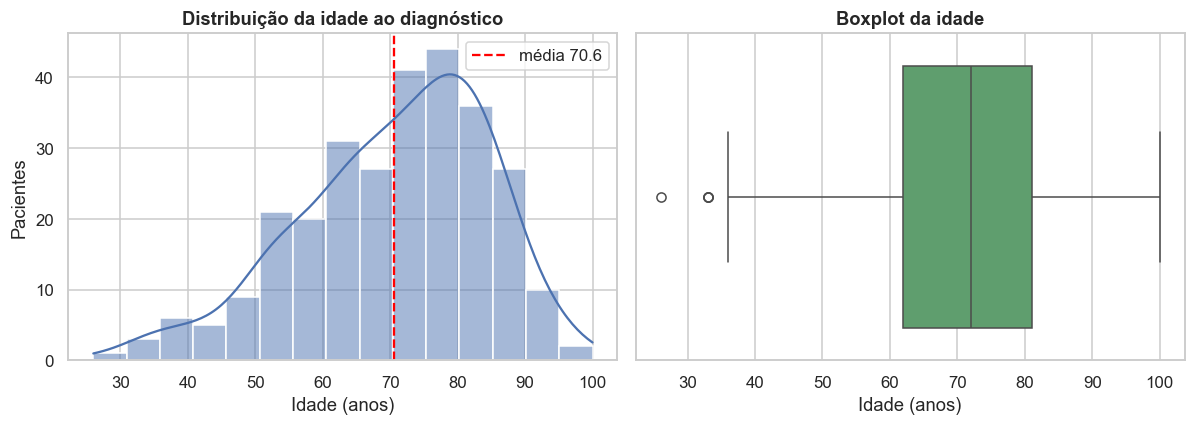

In [11]:
idade = df_paciente["idade"].dropna()
desc = idade.describe()[["count","mean","std","min","50%","max"]]
desc.index = ["n","média","desvio","mínimo","mediana","máximo"]
print(desc.round(1))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(idade, bins=15, kde=True, ax=axes[0], color="#4C72B0")
axes[0].axvline(idade.mean(), color="red", ls="--", label=f"média {idade.mean():.1f}")
axes[0].set(title="Distribuição da idade ao diagnóstico", xlabel="Idade (anos)", ylabel="Pacientes")
axes[0].legend()
sns.boxplot(x=idade, ax=axes[1], color="#55A868")
axes[1].set(title="Boxplot da idade", xlabel="Idade (anos)")
plt.tight_layout(); salvar_fig("01_idade.png"); plt.show()

### 3.2. Sexo

             n     %
sexo                
Masculino  170  59.6
Feminino   115  40.4


[figura salva] figuras\02_sexo.png


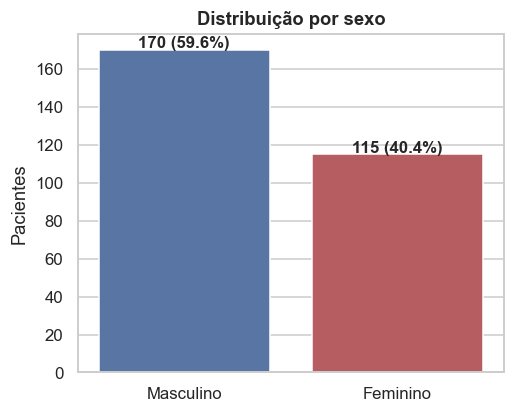

In [12]:
sx = df_paciente["sexo"].value_counts()
pct = (sx/sx.sum()*100).round(1)
print(pd.DataFrame({"n": sx, "%": pct}))

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=sx.index, y=sx.values, ax=ax, palette=["#4C72B0","#C44E52"])
for i,(v,p) in enumerate(zip(sx.values, pct.values)):
    ax.text(i, v+1, f"{v} ({p}%)", ha="center", fontweight="bold")
ax.set(title="Distribuição por sexo", xlabel="", ylabel="Pacientes")
salvar_fig("02_sexo.png"); plt.show()

### 3.3. Profissão (por setor)

                          n     %
profissao_grupo                  
Agrícola/rural          131  50.6
Comércio/serviços        33  12.7
Do lar                   28  10.8
Aposentado(a)            24   9.3
Construção/braçal        23   8.9
Saúde/educação/público   19   7.3
Desempregado              1   0.4


[figura salva] figuras\03_profissao.png


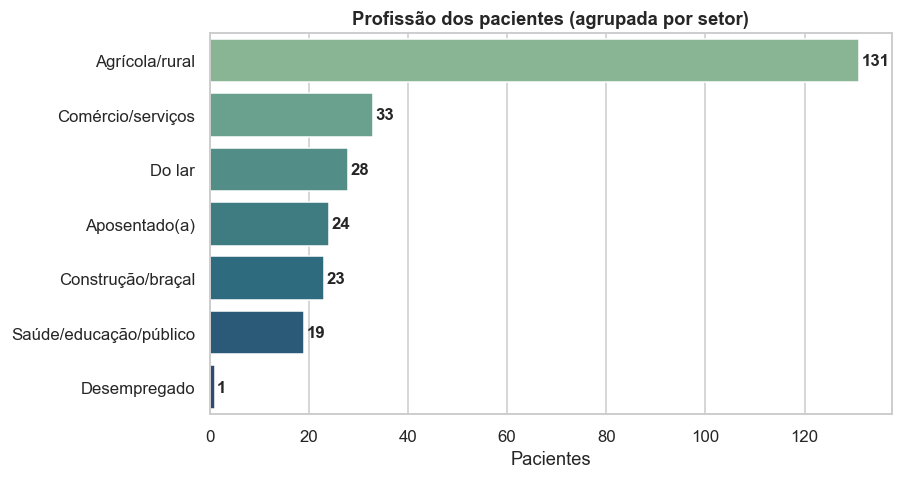


Top 10 profissões (texto original normalizado):
profissao
trabalhador agricola    127
do lar                   28
aposentado               23
professora                7
motorista                 6
comerciante               5
mecanico                  4
asg                       4
trabalhador de obras      4
carpinteiro               4
Name: count, dtype: int64


In [13]:
pg = df_paciente["profissao_grupo"].value_counts()
print(pd.DataFrame({"n": pg, "%": (pg/pg.sum()*100).round(1)}))

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(y=pg.index, x=pg.values, ax=ax, palette="crest")
for i, v in enumerate(pg.values): ax.text(v+0.5, i, str(v), va="center", fontweight="bold")
ax.set(title="Profissão dos pacientes (agrupada por setor)", xlabel="Pacientes", ylabel="")
salvar_fig("03_profissao.png"); plt.show()

print("\nTop 10 profissões (texto original normalizado):")
print(df_paciente["profissao"].value_counts().head(10))

### 3.4. Etnia e estado civil (complementar)

[figura salva] figuras\04_etnia_estadocivil.png


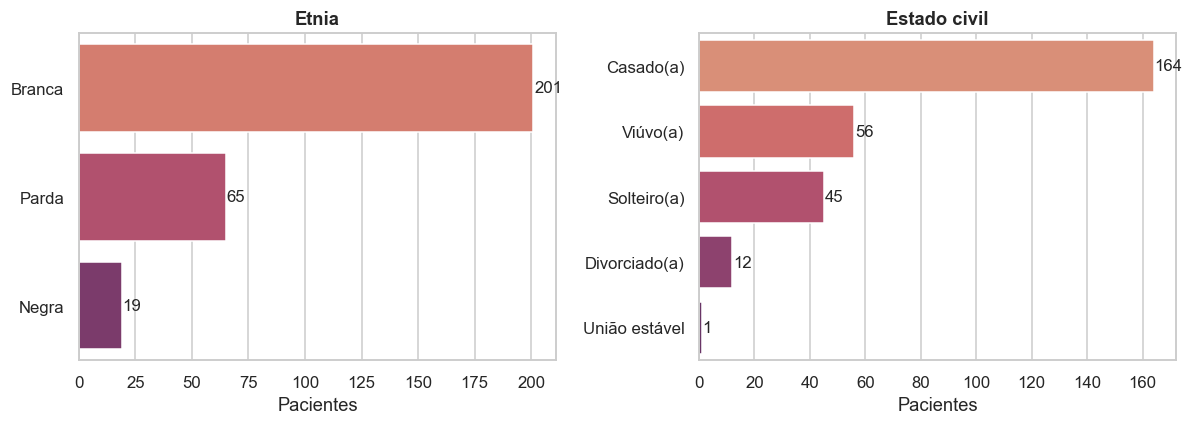

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, titulo in zip(axes, ["etnia","estado_civil"], ["Etnia","Estado civil"]):
    vc = df_paciente[col].value_counts()
    sns.barplot(y=vc.index, x=vc.values, ax=ax, palette="flare")
    for i, v in enumerate(vc.values): ax.text(v+0.3, i, str(v), va="center")
    ax.set(title=titulo, xlabel="Pacientes", ylabel="")
plt.tight_layout(); salvar_fig("04_etnia_estadocivil.png"); plt.show()

## 4. Comparação da idade média entre Homens e Mulheres
*(nível paciente)*

Verificamos normalidade (Shapiro-Wilk) e homogeneidade de variâncias (Levene) para escolher
entre **teste t de Welch** (paramétrico) e **Mann-Whitney** (não-paramétrico). Reportamos
p-valor e tamanho de efeito.

In [15]:
h = df_paciente.loc[df_paciente["sexo"]=="Masculino", "idade"].dropna()
m = df_paciente.loc[df_paciente["sexo"]=="Feminino", "idade"].dropna()

tab = pd.DataFrame({
    "n":[len(h), len(m)],
    "média":[h.mean(), m.mean()],
    "desvio":[h.std(), m.std()],
    "mediana":[h.median(), m.median()],
}, index=["Masculino","Feminino"]).round(1)
print(tab)

p_sh_h = stats.shapiro(h).pvalue; p_sh_m = stats.shapiro(m).pvalue
p_lev = stats.levene(h, m).pvalue
print(f"\nShapiro-Wilk normalidade: H p={p_sh_h:.3f} | M p={p_sh_m:.3f}")
print(f"Levene (variâncias iguais): p={p_lev:.3f}")

normal = p_sh_h > 0.05 and p_sh_m > 0.05
if normal:
    est, pval = stats.ttest_ind(h, m, equal_var=False)
    # d de Cohen
    sp = np.sqrt(((len(h)-1)*h.std()**2 + (len(m)-1)*m.std()**2)/(len(h)+len(m)-2))
    efe = (h.mean()-m.mean())/sp
    print(f"\nTeste t de Welch: t={est:.3f}, p={pval:.4f} | d de Cohen={efe:.3f}")
else:
    est, pval = stats.mannwhitneyu(h, m, alternative="two-sided")
    efe = 1 - 2*est/(len(h)*len(m))  # r (rank-biserial)
    print(f"\nMann-Whitney: U={est:.1f}, p={pval:.4f} | r (rank-biserial)={efe:.3f}")
print("Diferença significativa (α=0,05)?", "SIM" if pval < 0.05 else "NÃO")

             n  média  desvio  mediana
Masculino  168   69.6    13.9     72.0
Feminino   115   72.1    14.1     75.0

Shapiro-Wilk normalidade: H p=0.002 | M p=0.001
Levene (variâncias iguais): p=0.660

Mann-Whitney: U=8484.0, p=0.0820 | r (rank-biserial)=0.122
Diferença significativa (α=0,05)? NÃO


[figura salva] figuras\05_idade_por_sexo.png


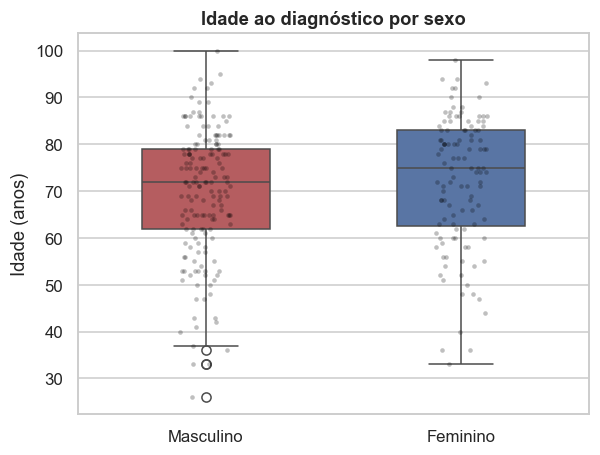

In [16]:
fig, ax = plt.subplots(figsize=(6, 4.5))
dados = df_paciente.dropna(subset=["idade","sexo"])
sns.boxplot(data=dados, x="sexo", y="idade", ax=ax, palette=["#C44E52","#4C72B0"], width=.5)
sns.stripplot(data=dados, x="sexo", y="idade", ax=ax, color="black", alpha=.25, size=3)
ax.set(title="Idade ao diagnóstico por sexo", xlabel="", ylabel="Idade (anos)")
salvar_fig("05_idade_por_sexo.png"); plt.show()

## 5. Tabelas cruzadas — características histopatológicas
*(nível lesão — todas as biópsias)*

Para cada cruzamento: tabela de contingência (n e % por linha), gráfico de barras,
e teste de associação. Usamos **qui-quadrado**; quando alguma frequência esperada < 5,
reportamos também **Fisher** (tabelas 2×2) ou sinalizamos a limitação.

In [17]:
def analisa_cruzamento(data, lin, col, titulo, arquivo, ordem_lin=None, ordem_col=None):
    sub = data.dropna(subset=[lin, col])
    ct = pd.crosstab(sub[lin], sub[col])
    if ordem_lin: ct = ct.reindex([x for x in ordem_lin if x in ct.index])
    if ordem_col: ct = ct[[x for x in ordem_col if x in ct.columns]]
    print(f"=== {titulo} ===  (n = {int(ct.values.sum())} lesões)")
    print("\nFrequências:"); print(ct)
    pct = ct.div(ct.sum(axis=1), axis=0).mul(100).round(1)
    print("\n% por linha:"); print(pct)

    chi2, p, dof, esp = stats.chi2_contingency(ct)
    min_esp = esp.min(); baixa = (esp < 5).mean()*100
    print(f"\nQui-quadrado: χ²={chi2:.3f}, gl={dof}, p={p:.4f}")
    print(f"Menor freq. esperada={min_esp:.2f} | % células com esperado<5: {baixa:.0f}%")
    if ct.shape == (2, 2):
        _, pf = stats.fisher_exact(ct)
        print(f"Fisher (2x2): p={pf:.4f}")
        p_uso = pf
    else:
        p_uso = p
        if min_esp < 5:
            print("⚠ Pressupostos do qui-quadrado parcialmente violados — interpretar com cautela.")
    print("Associação significativa (α=0,05)?", "SIM" if p_uso < 0.05 else "NÃO")

    fig, ax = plt.subplots(figsize=(8, 4.5))
    pct.plot(kind="bar", stacked=True, ax=ax, colormap="viridis")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set(title=titulo, xlabel="", ylabel="% das lesões (por linha)")
    ax.legend(title=col, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.xticks(rotation=20, ha="right")
    salvar_fig(arquivo); plt.show()
    return ct
print("função pronta")

função pronta


### 5.1. Subtipo (composição) × Grau de infiltração

=== Composição do tumor × Grau de infiltração ===  (n = 389 lesões)

Frequências:
grau_infiltracao  1. Derme  2. Derme reticular  3. Hipoderme/subcutâneo  \
composicao                                                                
Misto                   15                 194                       50   
Puro                    39                  67                       10   

grau_infiltracao  4. Estruturas profundas  
composicao                                 
Misto                                  13  
Puro                                    1  

% por linha:
grau_infiltracao  1. Derme  2. Derme reticular  3. Hipoderme/subcutâneo  \
composicao                                                                
Misto                  5.5                71.3                     18.4   
Puro                  33.3                57.3                      8.5   

grau_infiltracao  4. Estruturas profundas  
composicao                                 
Misto                                 

[figura salva] figuras\06_subtipo_x_grau.png


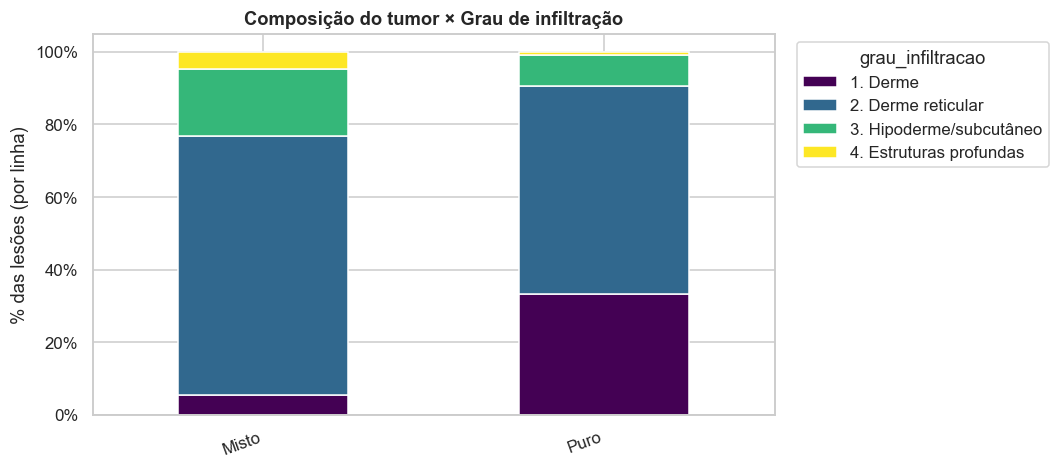

In [18]:
_ = analisa_cruzamento(df_lesao, "composicao", "grau_infiltracao",
        "Composição do tumor × Grau de infiltração", "06_subtipo_x_grau.png",
        ordem_col=ORDEM_GRAU)

Como complemento clínico, cruzamos a presença do componente **esclerodermiforme**
(padrão agressivo) com o grau de infiltração:

=== Componente esclerodermiforme × Grau de infiltração ===  (n = 389 lesões)

Frequências:
grau_infiltracao   1. Derme  2. Derme reticular  3. Hipoderme/subcutâneo  \
esclerodermiforme                                                          
Ausente                  21                  96                       21   
Presente                 33                 165                       39   

grau_infiltracao   4. Estruturas profundas  
esclerodermiforme                           
Ausente                                  2  
Presente                                12  

% por linha:


grau_infiltracao   1. Derme  2. Derme reticular  3. Hipoderme/subcutâneo  \
esclerodermiforme                                                          
Ausente                15.0                68.6                     15.0   
Presente               13.3                66.3                     15.7   

grau_infiltracao   4. Estruturas profundas  
esclerodermiforme                           
Ausente                                1.4  
Presente                               4.8  

Qui-quadrado: χ²=3.156, gl=3, p=0.3681
Menor freq. esperada=5.04 | % células com esperado<5: 0%
Associação significativa (α=0,05)? NÃO


[figura salva] figuras\06b_esclero_x_grau.png


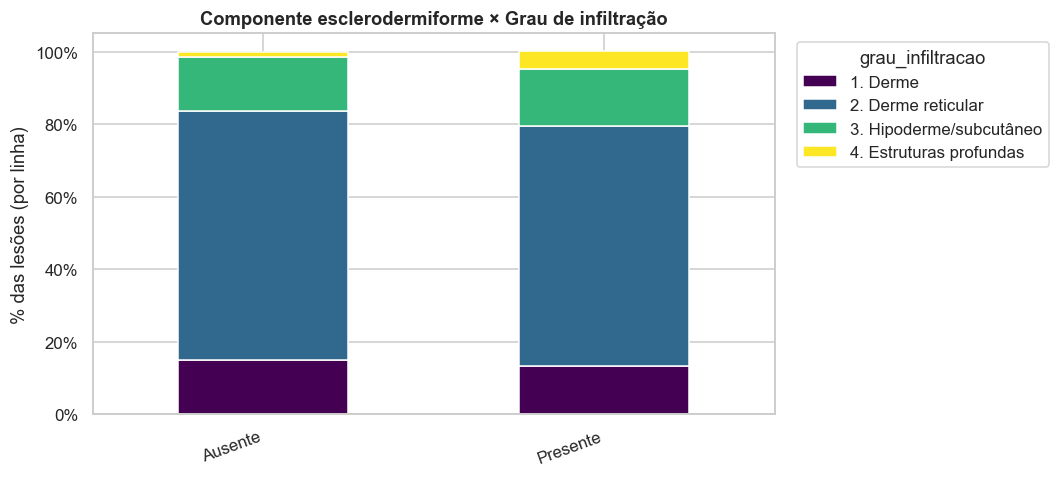

In [19]:
tmp = df_lesao.copy()
tmp["esclerodermiforme"] = tmp["tem_esclerodermiforme"].map({1:"Presente",0:"Ausente"})
_ = analisa_cruzamento(tmp, "esclerodermiforme", "grau_infiltracao",
        "Componente esclerodermiforme × Grau de infiltração",
        "06b_esclero_x_grau.png", ordem_col=ORDEM_GRAU)

### 5.2. Subtipo (composição) × Ulceração

=== Composição do tumor × Ulceração ===  (n = 415 lesões)

Frequências:
ulceracao   Não  Sim
composicao          
Misto       103  186
Puro         44   82

% por linha:
ulceracao    Não   Sim
composicao            
Misto       35.6  64.4
Puro        34.9  65.1

Qui-quadrado: χ²=0.001, gl=1, p=0.9766
Menor freq. esperada=44.63 | % células com esperado<5: 0%
Fisher (2x2): p=0.9116
Associação significativa (α=0,05)? NÃO


[figura salva] figuras\07_subtipo_x_ulceracao.png


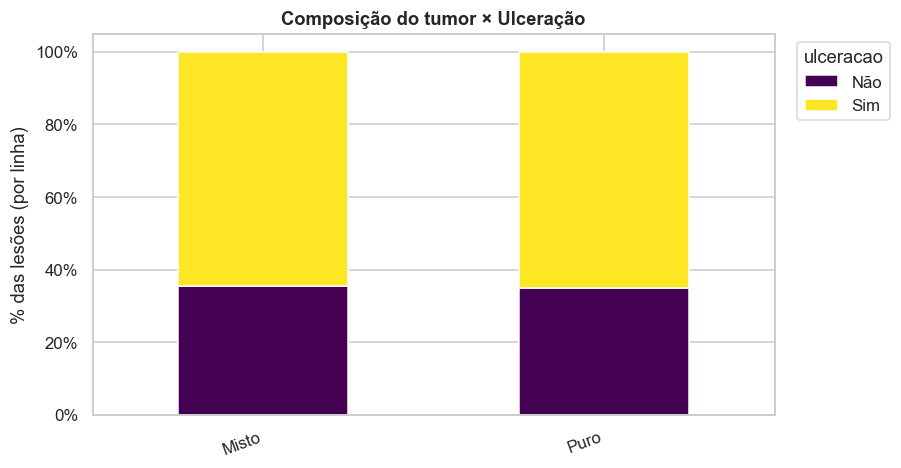

In [20]:
_ = analisa_cruzamento(df_lesao, "composicao", "ulceracao",
        "Composição do tumor × Ulceração", "07_subtipo_x_ulceracao.png",
        ordem_col=["Não","Sim"])

### 5.3. Subtipo × Invasão Linfovascular
⚠️ **Limitação:** a variável *Invasão Linfovascular* não possui nenhum caso positivo na base
(todos os registros preenchidos são `Não`; os demais estão em branco). Portanto **não há
variabilidade** e nenhum teste de associação é aplicável. Apresentamos apenas a contagem.

In [21]:
print("Invasão linfovascular (valores na base):")
print(df_lesao["inv_linfovascular"].value_counts(dropna=False))
print("\nPor composição do tumor:")
print(pd.crosstab(df_lesao["composicao"], df_lesao["inv_linfovascular"], dropna=False))
print("\n>> Sem casos positivos -> associação não avaliável.")

Invasão linfovascular (valores na base):
inv_linfovascular
NaN    219
Não    200
Name: count, dtype: int64

Por composição do tumor:
inv_linfovascular  Não  NaN
composicao                 
Misto              154  136
Puro                46   83

>> Sem casos positivos -> associação não avaliável.


### 5.4. Subtipo (composição) × Invasão Perineural

=== Composição do tumor × Invasão perineural ===  (n = 415 lesões)

Frequências:
inv_perineural  Não  Sim
composicao              
Misto           272   16
Puro            123    4

% por linha:
inv_perineural   Não  Sim
composicao               
Misto           94.4  5.6
Puro            96.9  3.1

Qui-quadrado: χ²=0.650, gl=1, p=0.4203
Menor freq. esperada=6.12 | % células com esperado<5: 0%
Fisher (2x2): p=0.4554
Associação significativa (α=0,05)? NÃO


[figura salva] figuras\08_subtipo_x_perineural.png


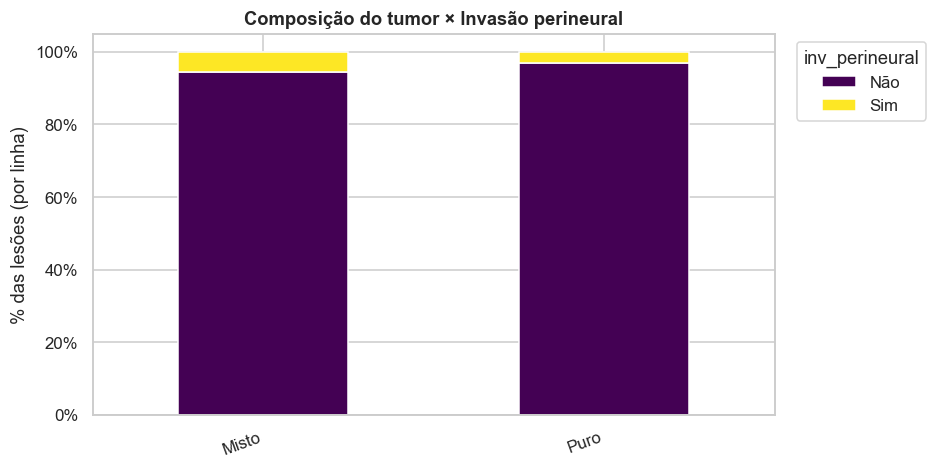

In [22]:
_ = analisa_cruzamento(df_lesao, "composicao", "inv_perineural",
        "Composição do tumor × Invasão perineural", "08_subtipo_x_perineural.png",
        ordem_col=["Não","Sim"])

Complemento: presença do componente esclerodermiforme × invasão perineural.

=== Componente esclerodermiforme × Invasão perineural ===  (n = 415 lesões)

Frequências:
inv_perineural     Não  Sim
esclerodermiforme          
Ausente            137    7
Presente           258   13

% por linha:
inv_perineural      Não  Sim
esclerodermiforme           
Ausente            95.1  4.9
Presente           95.2  4.8

Qui-quadrado: χ²=0.000, gl=1, p=1.0000
Menor freq. esperada=6.94 | % células com esperado<5: 0%
Fisher (2x2): p=1.0000
Associação significativa (α=0,05)? NÃO


[figura salva] figuras\08b_esclero_x_perineural.png


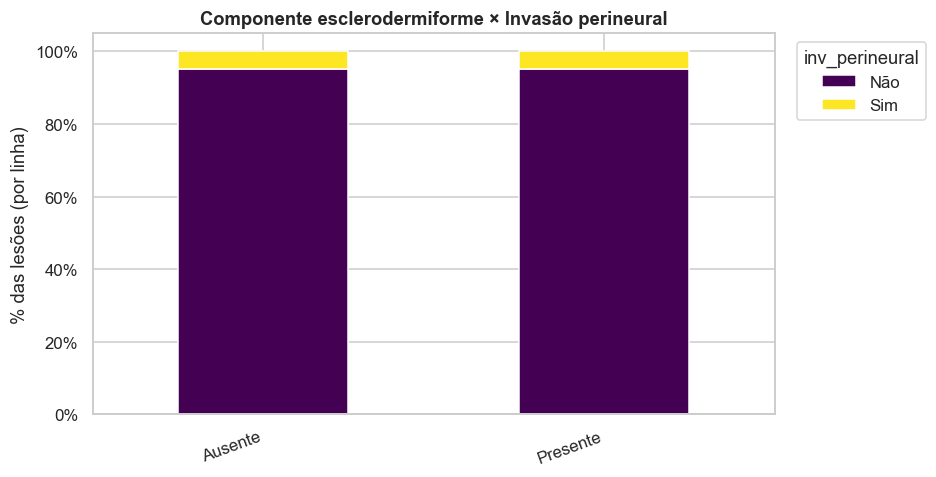

In [23]:
tmp = df_lesao.copy()
tmp["esclerodermiforme"] = tmp["tem_esclerodermiforme"].map({1:"Presente",0:"Ausente"})
_ = analisa_cruzamento(tmp, "esclerodermiforme", "inv_perineural",
        "Componente esclerodermiforme × Invasão perineural",
        "08b_esclero_x_perineural.png", ordem_col=["Não","Sim"])

### 5.5. Margens comprometidas × Reincidência

=== Margens × Reincidência ===  (n = 409 lesões)

Frequências:
reincidencia         Não  Sim
margem_comprometida          
Livre                348   11
Comprometida          41    9

% por linha:
reincidencia          Não   Sim
margem_comprometida            
Livre                96.9   3.1
Comprometida         82.0  18.0

Qui-quadrado: χ²=17.962, gl=1, p=0.0000
Menor freq. esperada=2.44 | % células com esperado<5: 25%
Fisher (2x2): p=0.0002
Associação significativa (α=0,05)? SIM


[figura salva] figuras\09_margens_x_reincidencia.png


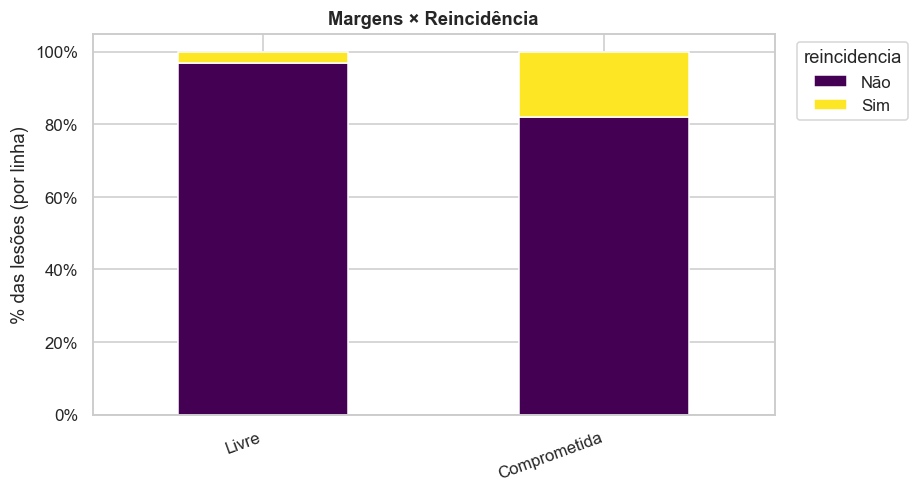

In [24]:
_ = analisa_cruzamento(df_lesao, "margem_comprometida", "reincidencia",
        "Margens × Reincidência", "09_margens_x_reincidencia.png",
        ordem_lin=["Livre","Comprometida"], ordem_col=["Não","Sim"])

## 6. Conclusões e limitações

**Perfil (285 pacientes):** idade média **70,6 anos** (mediana 72; 26–100), maioria **masculina
(59,6%)** e forte predomínio de **trabalhadores agrícolas/rurais (50,6%)** — coerente com CBC
associado à exposição solar crônica. Etnia predominante branca.

**Idade × sexo:** homens 69,6 anos vs. mulheres 72,1 anos. Distribuições não-normais (Shapiro
p<0,01) → **Mann-Whitney**: **p=0,082**, **sem diferença estatisticamente significativa** (efeito
pequeno, r≈0,12).

**Cruzamentos histopatológicos (nível lesão):**

| Cruzamento | Teste | p-valor | Resultado |
|---|---|---|---|
| Composição (puro/misto) × **Grau de infiltração** | Qui-quadrado | **<0,001** | **Significativo** — mistos infiltram mais profundamente (71% derme reticular + 18% hipoderme vs. puros 33% só na derme) |
| Composição × Ulceração | Qui-quadrado/Fisher | 0,98 | Não significativo (~65% ulceradas em ambos) |
| Composição × Invasão Linfovascular | — | — | Não avaliável (sem casos positivos) |
| Composição × Invasão Perineural | Qui-quadrado/Fisher | 0,42 | Não significativo (5,6% vs 3,1%) |
| Componente esclerodermiforme × Perineural | Fisher | 1,00 | Não significativo |
| **Margens comprometidas × Reincidência** | Fisher | **0,0002** | **Significativo** — comprometidas reincidem 18,0% vs. 3,1% das livres |

> **Destaques clínicos:** (1) a **composição mista** está associada a maior **profundidade de
> infiltração**; (2) **margens comprometidas** associam-se a maior **reincidência** — ambos
> coerentes com a literatura de CBC.

**Limitações dos dados:**
1. **Invasão linfovascular** sem casos positivos → associação não avaliável.
2. **Múltiplas lesões por paciente** (até 14 por código): os descritivos foram feitos por paciente,
   mas os cruzamentos histopatológicos usam lesões — observações não totalmente independentes.
3. **Dados ausentes** em várias colunas (grau, margens, reincidência) reduzem o n efetivo de cada teste.
4. **Subtipo** reconstruído a partir de texto livre — pequenas reclassificações são possíveis.
5. Análise **exploratória** de amostra única, sem ajuste para múltiplas comparações nem confundidores;
   associações significativas devem ser confirmadas em estudo dedicado.

**Arquivos gerados:** `dados_tratados.xlsx` (abas *por_lesao* e *por_paciente*) e figuras em `figuras/`.
